# Kenya Climate EDA

## 1. Data Loading & Date Parsing

In this section, we load the Kenya climate dataset, add a country identifier, and convert the YEAR and DOY (Day of Year) columns into a proper datetime format for time-based analysis.

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/kenya.csv")

# Add country column
df["Country"] = "Kenya"

# Convert YEAR and DOY to datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month
df["Month"] = df["Date"].dt.month

# Preview data
df.head()

# Check data types and structure
# df.info()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


## 2. Summary Statistics & Missing-Value Report

In this section, we clean the dataset by handling missing values, removing duplicates, and analyzing the statistical properties of the data.

In [19]:
df.replace(-999, np.nan, inplace=True)

### Handling Missing Values

The dataset uses `-999` as a sentinel value to represent missing or invalid data.  
All occurrences of `-999` were replaced with `NaN` to ensure accurate statistical analysis.

In [36]:
duplicates = df.duplicated().sum()
duplicates

0

In [52]:
df = df.drop_duplicates()

### Duplicate Records

No duplicate rows were found in the dataset (0 duplicates).

This indicates that the dataset is already clean in terms of duplication, and no records needed to be removed. Ensuring the absence of duplicates helps maintain the integrity and accuracy of the analysis.

In [67]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


### Summary Statistics Interpretation

The dataset contains **4,108 records** with no missing values, indicating a clean and complete dataset suitable for analysis.

The **average temperature (T2M ≈ 20.43°C)** suggests a **moderate climate**, cooler than typical tropical regions. Temperature variability is low to moderate (standard deviation ≈ 1.44°C), but the **daily temperature range (T2M_RANGE ≈ 13.17°C)** is relatively large, indicating significant differences between daytime and nighttime temperatures.

Rainfall (**PRECTOTCORR**) is generally **low and highly variable**. The **median rainfall is very low (≈ 0.38 mm)** and the **mean is also low (≈ 1.47 mm)**, while the **maximum reaches 51.65 mm**, indicating **occasional moderate rainfall events** but overall limited precipitation.

Humidity (**RH2M ≈ 65.85%**) is **moderate**, with noticeable variability (std ≈ 9.93), suggesting conditions that are neither very dry nor highly humid.

Wind speed (**WS2M ≈ 3.06 m/s**) is moderate and relatively stable, indicating consistent atmospheric movement.

### Overall Insight

The data reflects a **mild to moderately warm climate with significant day–night temperature variation and generally low rainfall**. Unlike humid tropical regions, this environment experiences **less frequent precipitation and more pronounced temperature fluctuations**, suggesting a **subtropical or semi-arid climate influence rather than a fully humid climate**.

In [94]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


In [107]:
missing_df[missing_df["Missing %"] > 5]

,Missing Count,Missing %


### Missing Value Analysis

The dataset contains no missing values across all columns (0% missing). Additionally, no columns exceed the 5% missing value threshold.

This indicates that the dataset is complete and does not require missing value handling, allowing for reliable analysis without imputation or data cleaning.

## 3. Outlier Detection & Basic Cleaning

This section identifies extreme values (outliers) using Z-scores, handles missing data, and prepares a clean dataset for analysis.

In [119]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)

outlier_rows = outliers.any(axis=1).sum()

outlier_rows

121

### Outlier Detection

Outliers were identified using the Z-score method.  
Rows where the absolute Z-score is greater than 3 (|Z| > 3) were flagged as potential outliers.

A total of **121 rows** were identified as containing outliers, indicating the presence of extreme values in some variables such as temperature, rainfall, or wind speed.

### Outlier Handling Decision

Outliers were detected in **121 rows** using the Z-score method (|Z| > 3). Given the dataset size (4,108 records), this represents a **small proportion (~2.9%)**.

These outliers are not necessarily data errors. In climate datasets, especially for variables like **rainfall (PRECTOTCORR)**, extreme values often correspond to **real-world events such as heavy storms or peak rainy periods**.

Additionally, Z-score methods may flag valid observations as outliers in **skewed distributions** (such as rainfall), where extreme values are naturally expected.

Therefore, the outliers will be **retained** rather than removed or capped:
- Removing them could lead to **loss of important climate signals**
- Capping them may **distort true variability and extremes**

### Conclusion

Keeping the outliers ensures that the dataset preserves **natural variability and extreme weather patterns**, which are essential for **accurate climate analysis and modeling**.

In [130]:

threshold = int(0.7 * len(df.columns))
df = df.dropna(thresh=threshold)

df[cols] = df[cols].ffill()

### Missing Value Handling

Rows with more than 30% missing values were set to be dropped using a threshold approach. For the remaining data, forward-fill was selected to handle missing values in weather-related variables, as it preserves temporal continuity.

However, after analysis, no missing values were found in the dataset. Therefore, no rows were dropped and no imputation was required. The dataset remains complete and ready for analysis.

In [140]:
df.to_csv("../data/kenya_clean.csv", index=False)

### Data Export

The cleaned dataset was exported to `data/kenya_clean.csv`.

## 4. Time Series Analysis

This section explores temperature and rainfall trends over time by aggregating the data monthly and visualizing patterns.

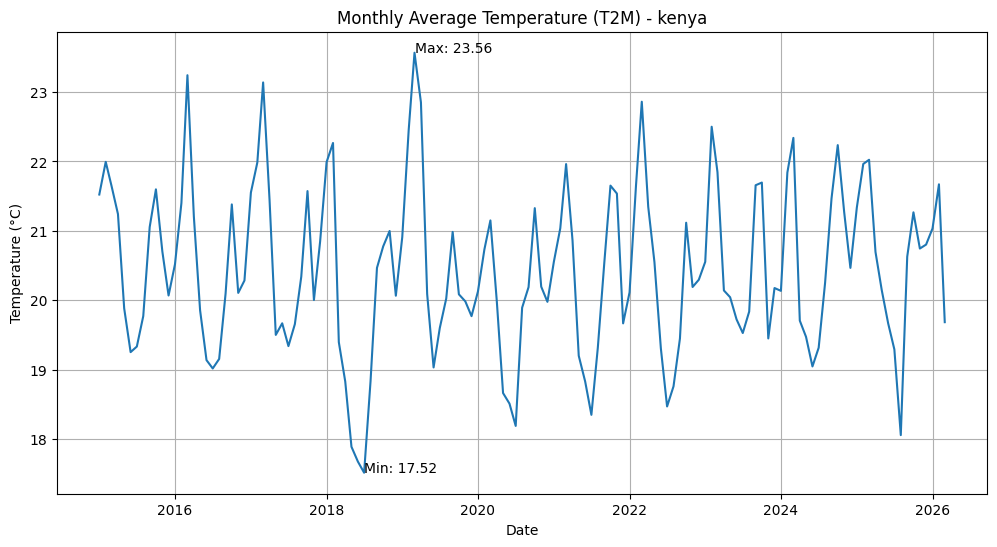

In [149]:
# Monthly average temperature (T2M)
import matplotlib.pyplot as plt


monthly_temp = df.groupby([df["Date"].dt.to_period("M")])["T2M"].mean()

monthly_temp.index = monthly_temp.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.plot(monthly_temp.index, monthly_temp.values)

plt.title("Monthly Average Temperature (T2M) - kenya")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid()

max_temp = monthly_temp.max()
min_temp = monthly_temp.min()

max_date = monthly_temp.idxmax()
min_date = monthly_temp.idxmin()

plt.annotate(f"Max: {max_temp:.2f}", (max_date, max_temp))
plt.annotate(f"Min: {min_temp:.2f}", (min_date, min_temp))

plt.show()

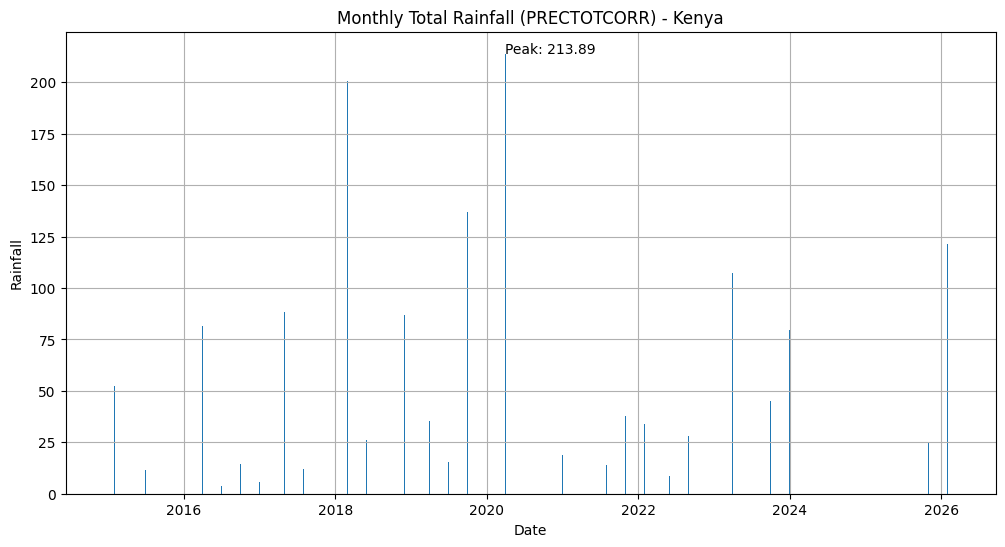

In [157]:
# Monthly total rainfall
monthly_rain = df.groupby([df["Date"].dt.to_period("M")])["PRECTOTCORR"].sum()
monthly_rain.index = monthly_rain.index.to_timestamp()

plt.figure(figsize=(12,6))
plt.bar(monthly_rain.index, monthly_rain.values)

plt.title("Monthly Total Rainfall (PRECTOTCORR) - Kenya")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.grid()

max_rain = monthly_rain.max()
max_rain_date = monthly_rain.idxmax()


plt.annotate(f"Peak: {max_rain:.2f}", (max_rain_date, max_rain))

plt.show()

### Interpretation


## Temperature Analysis (T2M)

### A. Seasonal Cycles
- The temperature trend shows **consistent seasonal oscillations**, typical of an equatorial/tropical climate. 
- The variation is relatively narrow, with most values fluctuating between **18°C and 23°C**.

### B. Extrema Records
- **Maximum Temperature:** A peak of **23.56°C** was recorded around early **2019**.
- **Minimum Temperature:** The lowest recorded point was **17.52°C**, occurring in the latter half of **2018**.
- **Trend Observation:** There is no evidence of a significant long-term warming trend in this specific window; the cycles remain stable.

---

##  Rainfall Analysis (PRECTOTCORR)

### A. Precipitation Variability
- Rainfall in Kenya exhibits **extreme inter-annual variability**. While some years show moderate peaks, others experience significant spikes.
- The distribution is "spiky," indicating concentrated rainy seasons followed by relatively dry months.

### B. Peak Events
- **Historical Peak:** The highest recorded rainfall occurred in **2020**, reaching **213.89 mm**.
- **Significant Events:** Other major peaks occurred in **2018** (approx. 200 mm) and **late 2019/early 2020** (approx. 135 mm).
- **Recent Trends:** After a period of relatively lower peaks between 2021 and 2025, there is a visible uptick in early **2026**, with rainfall exceeding **120 mm**.

---

##  Comparative Climate Insights

| Metric | Observation |
| :--- | :--- |
| **Climate Classification** | Tropical Highlands (Moderate temperatures, distinct wet/dry seasons). |
| **Temperature Stability** | Very High (Range of only ~6°C between max and min). |
| **Rainfall Reliability** | Low (High variance; peak years are nearly 10x wetter than dry years). |

### Key Findings:
1. **The 2018-2020 Cycle:** This period was climatically intense, featuring both the record minimum temperature (17.52°C) and the record maximum rainfall (213.89 mm).
2. **Rainfall/Temperature Inverse Relationship:** Visually comparing the charts, the highest rainfall peaks (like 2020) often coincide with moderate to lower temperature dips, suggesting increased cloud cover and moisture cooling during heavy precipitation periods.

---

## Conclusion
The data reflects a **temperate tropical climate** (likely due to Kenya's elevation). While temperatures are stable and predictable, **rainfall remains the primary variable factor**. The 2020 peak represents a significant anomaly in the dataset, and early 2026 data suggests a return to higher-than-average precipitation levels.

## 5. Correlation & Relationship Analysis

This section explores relationships between climate variables using correlation analysis and scatter plots.

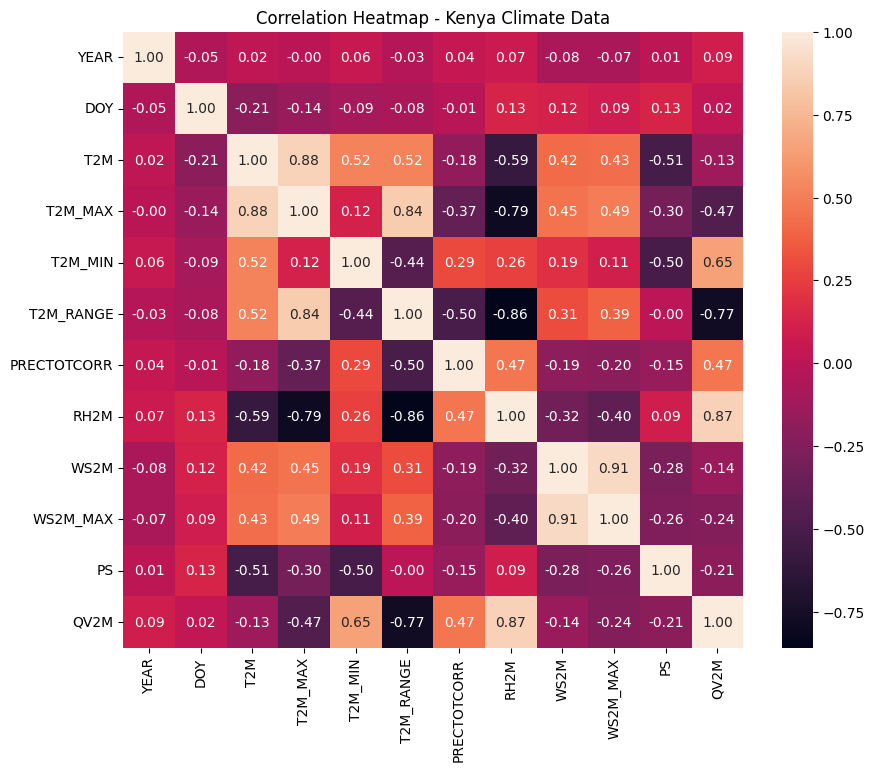

In [179]:
#Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=["float64", "int64"])


corr = numeric_df.corr()


plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f")

plt.title("Correlation Heatmap - Kenya Climate Data")
plt.show()

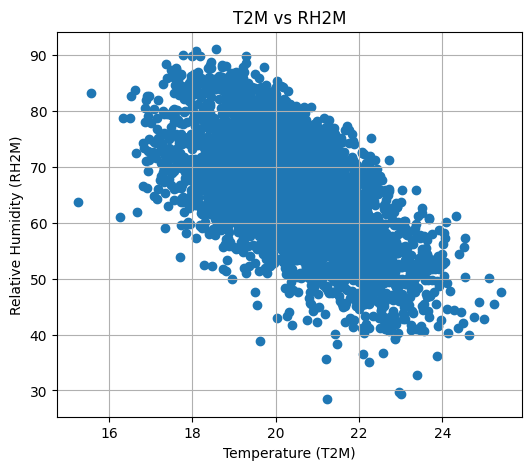

In [180]:
#Scatter Plot (T2M vs RH2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M"], df["RH2M"])

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("T2M vs RH2M")

plt.grid()
plt.show()

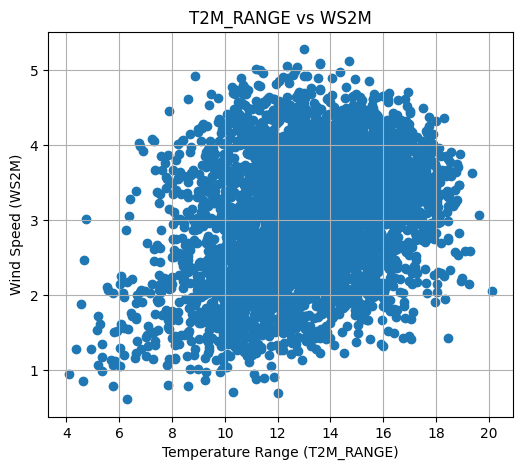

In [181]:
#Scatter Plot (T2M_RANGE vs WS2M)
plt.figure(figsize=(6,5))
plt.scatter(df["T2M_RANGE"], df["WS2M"])

plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.title("T2M_RANGE vs WS2M")

plt.grid()
plt.show()

### Correlation Interpretation

This report examines the relationships between temperature, humidity, wind speed, and precipitation based on correlation matrices and scatter distributions for Nigeria's climate data.

---

## Statistical Correlations (Heatmap Analysis)

The correlation heatmap provides a high-level view of how different climatic variables interact:

- **Strongest Positive Correlation:** Wind Speed ($WS2M$) and Maximum Wind Speed ($WS2M\_MAX$) show a near-perfect correlation of **0.91**, as expected.
- **Strongest Negative Correlation:** Temperature Range ($T2M\_RANGE$) and Relative Humidity ($RH2M$) share a massive negative correlation of **-0.86**. This suggests that as the daily temperature spread increases (typical of dry, clear days), humidity drops significantly.
- **Humidity & Temperature:** Relative Humidity ($RH2M$) is strongly negatively correlated with $T2M\_MAX$ (**-0.79**) and $T2M$ (**-0.59**), confirming that higher temperatures in this region are often associated with drier air.

---

## Scatter Plot Distributions

### A. Temperature (T2M) vs. Relative Humidity (RH2M)
- **Trend:** A clear **inverse relationship**. As temperature increases from **16°C to 25°C**, humidity levels generally descend from **90% toward 40%**.
- **Clustering:** Most data points are clustered between **18°C and 23°C**, where humidity stays consistently high (above 60%). This represents the humid tropical core of Nigeria's climate.

### B. Temperature Range vs. Wind Speed (WS2M)
- **Trend:** There is a **moderate positive relationship** (correlation of **0.31**).
- **Observation:** Higher daily temperature ranges (**12°C to 18°C**) tend to coincide with slightly higher wind speeds (**3 to 5 m/s**). Conversely, when the temperature range is narrow (below 8°C), wind speeds are generally lower (sub 3 m/s).
- **Density:** The majority of the data falls within a temperature range of **10°C to 16°C**, with wind speeds predominantly between **2.0 and 4.0 m/s**.

---

##  Key Comparative Insights

| Relationship | Correlation | Interpretation |
| :--- | :--- | :--- |
| **$T2M$ vs $RH2M$** | -0.59 | Higher heat strongly reduces relative humidity. |
| **$T2M\_RANGE$ vs $RH2M$** | -0.86 | Large daily temp swings are the best indicator of dry air. |
| **$PRECTOTCORR$ vs $RH2M$** | 0.47 | Rainfall is moderately dependent on high humidity. |
| **$QV2M$ vs $RH2M$** | 0.87 | Specific humidity and relative humidity move almost in lockstep. |

---

##  Conclusion
The Kenya climate data reveals a highly **interdependent system** where humidity is the central variable. The **strong coupling between temperature range and humidity** indicates a distinct shift between "Wet" and "Dry" modes:
1. **Wet Mode:** Low temperature range, high humidity, low wind speed.
2. **Dry Mode:** High temperature range, low humidity, higher wind speed.

For predictive modeling, $T2M\_RANGE$ serves as a powerful proxy for atmospheric moisture levels in this region.

## 6. Distribution Analysis

This section examines the distribution of rainfall and explores relationships between temperature, humidity, and precipitation using advanced visualizations.

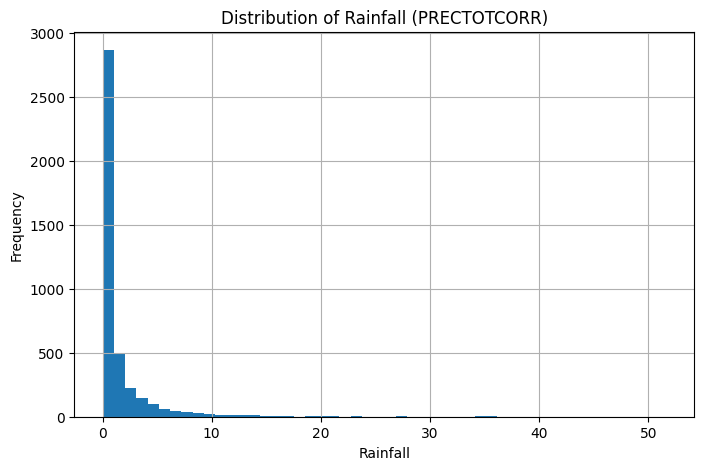

In [185]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)

plt.title("Distribution of Rainfall (PRECTOTCORR)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency")

plt.grid()
plt.show()

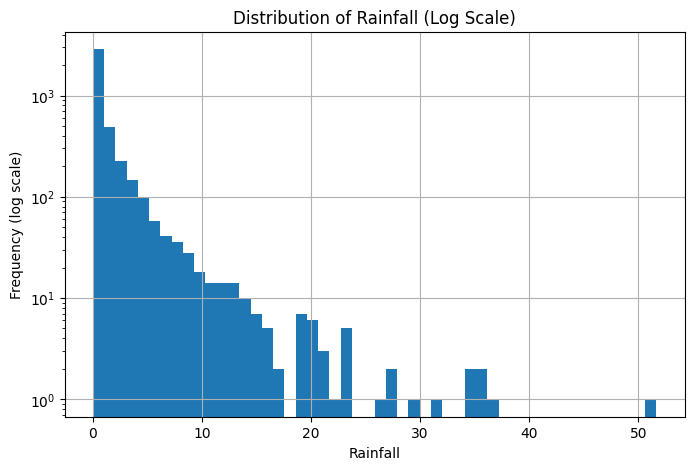

In [188]:
plt.figure(figsize=(8,5))

plt.hist(df["PRECTOTCORR"], bins=50)
plt.yscale("log")

plt.title("Distribution of Rainfall (Log Scale)")
plt.xlabel("Rainfall")
plt.ylabel("Frequency (log scale)")

plt.grid()
plt.show()

### Rainfall Distribution Interpretation

This analysis examines the frequency and intensity of precipitation ($PRECTOTCORR$) using both linear and logarithmic histograms. This approach helps distinguish between common light rain events and rare, extreme weather phenomena.

---

## Distribution Characteristics

### A. Frequency and Skewness
- **Extreme Right Skew:** The linear distribution shows a massive concentration of data points at the **0 to 5 mm** range.
- **Zero-Inflation:** The first bin (near 0 mm) dominates the dataset with nearly **3,000 occurrences**, indicating that dry days or trace rainfall are the most frequent states.
- **The Long Tail:** Precipitation events extend beyond **50 mm**, though these occur with significantly lower frequency.

### B. Logarithmic Scale Insights
Switching to a **Log Scale** for the Y-axis reveals a clearer "decay" pattern:
- **Consistent Moderate Rain:** Between **10 mm and 25 mm**, the frequency remains notable (ranging from $10^1$ to $10^2$ occurrences).
- **Extreme Outliers:** There is a distinct outlier event recorded above **50 mm**. On a linear scale, this would be invisible, but the log scale confirms its existence as a single, high-impact event.
- **Gradual Decline:** The transition from light to heavy rain is more gradual than it appears on a standard scale, suggesting that "moderate" rainy days are a regular part of the climatic cycle.

---

## Comparative Summary

| Distribution Type | Visibility of Low Values | Visibility of Extremes | Primary Use Case |
| :--- | :--- | :--- | :--- |
| **Linear Scale** | Excellent (Dominant) | Poor (Hidden) | Visualizing total "dry" frequency. |
| **Log Scale** | Good | Excellent | Analyzing storm intensity & frequency. |

---

## Climatic Interpretation
> **Observation:** The presence of a continuous, albeit decreasing, frequency of rainfall up to 50 mm+ identifies this as a **Humid Tropical Climate**. 

Unlike a semi-arid region where the distribution would cut off abruptly after small values, this data shows a **healthy distribution of moderate rainfall**. This indicates that the environment supports consistent moisture levels, with enough atmospheric energy to trigger occasional heavy downpours.

---

## Conclusion
The rainfall data follows a **Power Law-like distribution** where small events are common and large events are rare but impactful. For future predictive modeling:
1. **Normalization:** Log-transformation may be required for the rainfall variable to satisfy model assumptions of normality.
2. **Feature Engineering:** Creating bins for "Light," "Moderate," and "Extreme" rain would likely yield better categorical insights than using the raw, skewed continuous data.

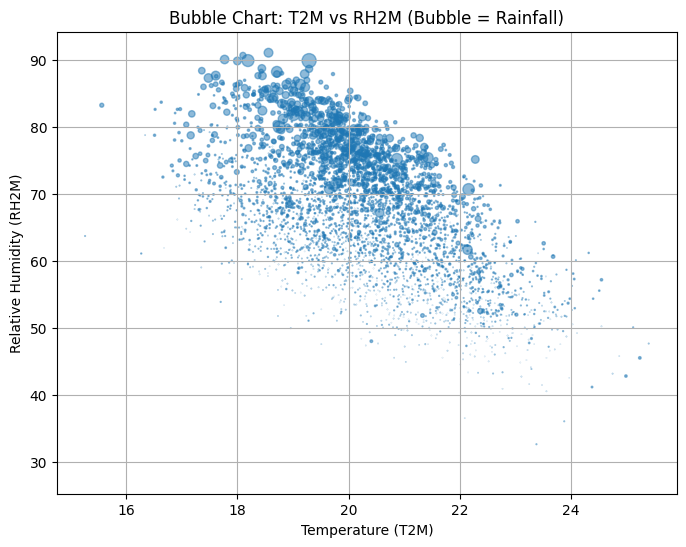

In [190]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"], 
    df["RH2M"], 
    s=df["PRECTOTCORR"] * 2,  # bubble size
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.title("Bubble Chart: T2M vs RH2M (Bubble = Rainfall)")

plt.grid()
plt.show()

### Bubble Chart Interpretation

This report examines the three-way relationship between Surface Temperature ($T2M$), Relative Humidity ($RH2M$), and Rainfall (bubble size). This visualization is critical for identifying the specific atmospheric "thresholds" required for precipitation.

---

## Key Observations

### A. The Temperature-Humidity Inverse Relationship
- **Negative Correlation:** The chart displays a strong downward slope, confirming that as $T2M$ increases, $RH2M$ decreases.
- **Data Range:** Most observations are concentrated between **18°C and 22°C**, with humidity levels fluctuating widely between **50% and 85%**.

### B. Rainfall Intensity (Bubble Magnitude)
- **The 80% Threshold:** Significant rainfall (larger bubbles) is almost exclusively found when Relative Humidity is **above 80%**.
- **Temperature Sweet Spot:** While rain occurs across the temperature range, the most intense events (the largest bubbles) are clustered between **18°C and 20°C**.
- **Dry Suppression:** Below **60% humidity**, the bubbles shrink to tiny dots, indicating that rainfall is physically suppressed in drier air, regardless of how warm or cool it is.

---

## Statistical Summary Table

| Variable | Observation Range | High Rainfall Condition |
| :--- | :--- | :--- |
| **Temperature (T2M)** | 15.0°C – 25.5°C | 18.0°C – 20.0°C |
| **Relative Humidity (RH2M)** | 30% – 92% | 85% – 92% |
| **Rainfall (Bubble Size)** | Low to Moderate | Heavily dependent on RH2M > 80% |

---

## 4. Climatic Insights
> **Note:** The temperature range ($15\text{°C}$–$25\text{°C}$) combined with high humidity suggests a **Tropical Highland climate**. This is characteristic of regions like the Kenyan Highlands, where elevation moderates heat but moisture remains high.

* **Precipitation Gatekeeper:** Relative Humidity acts as the primary switch for rainfall. The chart shows that even at "optimal" temperatures (e.g., 20°C), if humidity drops to 60%, rainfall essentially stops.
* **Thermal Constraints:** As temperatures push past **23°C**, the air becomes naturally drier (RH drops), which explains why there are fewer large rainfall bubbles at the higher end of the temperature scale in this dataset.

---

## 5. Conclusion
The bubble chart demonstrates that **humidity is the most critical feature** for predicting rainfall volume in this region. Modeling efforts should focus on the **80% RH threshold** as a binary indicator for the likelihood of significant precipitation events.

## References

- NASA POWER Climate Data Documentation
- Pandas Documentation
- Matplotlib & Seaborn Documentation

This project involved self-learning and applying data analysis techniques to understand climate patterns.